<a href="https://colab.research.google.com/github/AIPI510/aipi510-fall24/blob/lecture-code/week_5_lecture_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis of 2020 Welltory COVID-19 Research
### AIPI 510: Sourcing Data for Analytics 
### Caleb McNeill

## Data Context
Welltory researched and tracked symptoms, heart rate variability, and other relevant data of patients in 2020 with a positive COVID-19 diagnosis. The following Exploratory Data Analysis explores various types of data collected by the study. Heart rate variability data was collected by Photoplethysmography (PPG), an optical technique to detect blood volume changes in microvascular beds of tissue to track heartbeat. Supplemental data was collected by various methods including surveys with connected devices that sync with the apps Google Fit or Apple Health. The EDA here explores primarily the survey data taken by the applications.

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Load the datasets
df_blood_pressure = pd.read_csv('blood_pressure.csv')
df_weather = pd.read_csv('weather.csv')
df_heart_rate = pd.read_csv('heart_rate.csv')
df_hrv_measure = pd.read_csv('hrv_measurements.csv')
df_participants = pd.read_csv('participants.csv')
df_scales_desc = pd.read_csv('scales_description.csv')
df_sleep = pd.read_csv('sleep.csv')
df_surveys = pd.read_csv('surveys.csv')
df_wearables = pd.read_csv('wearables.csv')

#Explore data

df_surveys.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2259 entries, 0 to 2258
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_code   2259 non-null   object
 1   scale       2259 non-null   object
 2   created_at  2259 non-null   object
 3   value       2259 non-null   int64 
 4   text        2259 non-null   object
dtypes: int64(1), object(4)
memory usage: 88.4+ KB


# Why Surveys?
I chose the surveys because it is a complete dataset that provides a numeric value on the severity of the COVID-19 symptoms the patients stated they were feeling, objectively quantifying the symptoms into data points we can analyze graphically. I assume the results are measured from the patients' perceptions of the severity of their symptoms as opposed to a health provider's perception due to the nature of the surveys most likely collected by the apps.

## Questions we are asking:
* What are the dimensions of the dataset (number of rows and columns)?
* What are the data types of the variables (numerical, categorical, text, etc.)?
* Are there any missing values, and if so, how are they represented?


In [28]:
# Data Structure
print("Data Structure")
print("---------------")
print(f"Dimensions: {df_surveys.shape}")
print(f"Data Types:\n{df_surveys.dtypes}")
print(f"Missing Values:\n{df_surveys.isnull().sum()}")
print(f"Numeric attributes:\n{df_surveys['value'].describe()}")


Data Structure
---------------
Dimensions: (2259, 5)
Data Types:
user_code     object
scale         object
created_at    object
value          int64
text          object
dtype: object
Missing Values:
user_code     0
scale         0
created_at    0
value         0
text          0
dtype: int64
Numeric attributes:
count    2259.000000
mean        2.364763
std         1.554934
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max         6.000000
Name: value, dtype: float64


##Interpretation

This indicates that there are 2259 observations (samples) of COVID-19 surveys, with each observation having 4 feature measurements and 1 target (user-code) label.

The numerical features represent the quantified severity of the COVID-19 symptoms on a perceived scale of 1-6, while the categorical features represent separate symptoms, times collected, and descriptive text of the severity.

The dataset is complete, and no imputation or deletion of rows/columns is necessary.

## Questions we are asking:
* What are the central tendency measures (mean, median, mode) for numerical variables?
* What are the measures of dispersion (range, variance, standard deviation) for numerical variables?
* What is the distribution of the variables (normal, skewed, etc.)?


In [ ]:
# Descriptive Statistics
print("\nDescriptive Statistics")
print("----------------------")
numeric_columns = df_surveys.select_dtypes(include=[np.number]).columns
print("Central Tendency Measures:")
print(df_surveys[numeric_columns].describe().loc[['mean', '50%']])
print(f"Mode: {df_surveys['value'].mode()}")
print("\nDispersion Measures:")
print(df_surveys[numeric_columns].describe().loc[['std', 'min', 'max']])

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print("------------------------")
print("Skewness:")
print(df_surveys[numeric_columns].skew())
print("Kurtosis:")
print(df_surveys[numeric_columns].kurt())


Descriptive Statistics
----------------------
Central Tendency Measures:
         value
mean  2.364763
50%   2.000000
Mode: 0    1
Name: value, dtype: int64

Dispersion Measures:
        value
std  1.554934
min  1.000000
max  6.000000

Distribution Measures:
------------------------
Skew:
value    0.862598
dtype: float64
Kurtosis:
value   -0.450001
dtype: float64


## Interpretation

#### Descriptive Statistics
The mean, median, and mode provide insights indicating that most of the data falls left of the center point of a 1-6 scale. For example, the median value is 2.0 with a mean of around 2.36, while the mode is 1, indicating most data points falling left of center and indicating what may be a right tail.

#### Dispersion Measures
These measures give us further understanding of the spread and range of the data. The range of the data is seemingly constrained to a scale between 1 and 6. The deviation from the mean at over a quarter of the value of the range suggests that there are a fairly varied range of responses outside of the mean value.

#### Distribution Measures
Distribution Measures: Skewness and kurtosis of the numerical features. The 0.86 value of Skewness further indicates a right tail which may indicate the need for a transformation, though the kurtosis of the data suggests the data may carry robust tails on either side of the bell curve.

## Questions we are asking:
* Are there any duplicated rows or inconsistent values?
* Are there any outliers or extreme values that need attention?
* Do the values make sense based on the context and domain knowledge?


In [34]:
# Data Quality
print("\nData Quality")
print("------------")
print(f"Duplicated Rows: {df_surveys.duplicated().sum()}")
print("Checking for Inconsistent Values:")
print(df_surveys.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))


Data Quality
------------
Duplicated Rows: 0
Checking for Inconsistent Values:
                        most_frequent_value
user_code                        6be5033971
scale                       S_COVID_FATIGUE
created_at                       2020-05-03
value                                     1
text        User isn’t experiencing symptom


## Interpretation

Duplicated Rows: There are no duplicated rows in the dataset.


Inconsistent Values: The most frequent values (1 in 'value') show that there are not egregious data points outside the dataframe that are skewing the data tremendously.

## Questions we are asking:

* Is there any correlation between pairs of numerical variables?
* Are there any noticeable patterns or trends in the data?
* How are categorical variables related to numerical variables?


In [ ]:
# Variable Relationships

print("\nVariable Relationships")
print("----------------------")

#Encode the "scale" object categories
encoded = pd.get_dummies(
    df_surveys,
    columns=["scale"],
    drop_first=False,
    dtype=int
)

df_corr = encoded.corr(method="spearman", numeric_only=True)
print(df_corr['value'].sort_values(ascending=False))



Variable Relationships
----------------------
value                      1.000000
scale_S_COVID_OVERALL      0.273915
scale_S_COVID_FATIGUE      0.216472
scale_S_HEART              0.128043
scale_S_COVID_COUGH        0.109159
scale_S_HRA_ALC            0.077749
scale_S_COVID_PAIN         0.074413
scale_S_COVID_SYMPTOMS     0.043059
scale_S_CORONA             0.031459
scale_S_DIABETES           0.010854
scale_S_COVID_BREATH       0.003728
scale_S_HRA_DBT            0.003314
scale_S_COVID_TROUBLE     -0.014659
scale_S_HRA_HBP           -0.021422
scale_S_HRA_EPILEPSY      -0.021422
scale_S_HRA_HORM          -0.021422
scale_S_HEART_4           -0.021422
scale_S_HRA_ENDO          -0.021422
scale_S_HRA_EDEMA         -0.021422
scale_S_HRA_OCD           -0.021422
scale_S_HEART_5           -0.021422
scale_S_DIAB_REASON4      -0.021422
scale_S_DIAB_REASON6      -0.021422
scale_S_DIAB_REASON1      -0.021422
scale_S_DIAB_REASON2      -0.021422
scale_S_COVID_FEVER       -0.024987
scale_S_HRA_HEAVY

'\nprint("\nVariable Relationships")\nprint("----------------------")\nprint("Correlation Matrix:")\ncorrelation_matrix = df_surveys[cat_columns].corr()\nprint(correlation_matrix)\n\n# Visualize the Correlation Matrix\nplt.figure(figsize=(10, 8))\nsns.heatmap(correlation_matrix, annot=True, cmap=\'coolwarm\', fmt=\'.2f\', linewidths=.5)\nplt.title(\'Correlation Matrix Heatmap\')\nplt.show()\n'

## Interpretation

Positive Correlation values (closer to 1) indicator stronger correlation relationships. No severity values of COVID designated particularly strong correlations with the scale of symptoms provided. This may suggest that symptoms spanned widely throughout severity levels.

## Questions we are asking:

* How can the variables be visualized effectively (histograms, scatterplots, box plots, etc.)?
* Do the visualizations reveal any interesting patterns or insights?
* Are there any subgroups or clusters that can be identified visually?


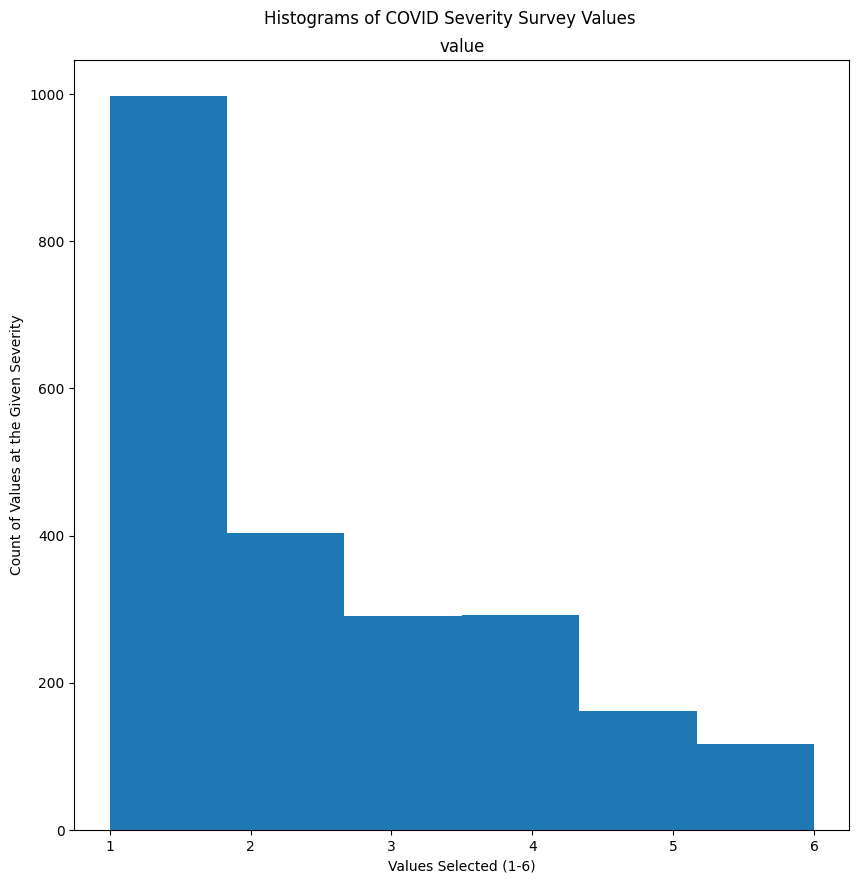

In [58]:

# Visualize distributions
df_surveys[numeric_columns].hist(bins=6, figsize=(10,10), grid=False)
plt.suptitle('Histograms of COVID Severity Survey Values', y=0.93)
plt.xlabel('Values Selected (1-6)')
plt.ylabel('Count of Values at the Given Severity')
plt.show()



## Interpretation

#### Histograms:

The histogram shows a large right skew and tail in the data suggesting that a large majority of the participants reported lesser or mild symptoms with much fewer reporting severe or extreme severity. I chose the histogram because it best represented the counts of the whole value selections for the overall totals of the dataset.
